# SWGO L07 Detector Optimization (Refactored)

All utility functions have been extracted into separate Python modules.
This notebook preserves the original optimization logic.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Standard library imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
import copy
import warnings
import matplotlib.patches as patches
from pathlib import Path
from matplotlib import colors
from matplotlib.colors import LogNorm, Normalize
from torch.utils.data import TensorDataset, DataLoader
import os
import gc

# Extracted module imports
from shower_generation import GenerateShowers
from detector_response import GetCounts_differentiable, SmearN, TimeAverage_vectorized
from geometry import Layouts
from reconstruction import Reconstruction, NormalizeLabels, DenormalizeLabels, EarlyStopping
from layout_optimization import LearnableXY, push_apart, symmetry_loss
from utility_functions import reconstructability, U_PR, U_E, U_angle

output_dir = "./outputs/NN_Files_26_20k_from_center"
os.makedirs(output_dir, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Constants and Parameters

In [3]:
# Matrices used in shower parametrization
A = torch.tensor([[1, 1, 1, 1],[1, 2, 4, 8], [1, 3, 9, 27], [1, 4, 16, 64]], dtype=torch.float32)

# Constants
c0 = .29979  # Speed of light in [m / ns]
theta_max = np.pi * 65 / 180
log_01 = torch.tensor([np.log(.1)], dtype=torch.float32)
log_10 = torch.tensor([np.log(10)], dtype=torch.float32)
sqrt12 = torch.tensor([np.sqrt(12)], dtype=torch.float32)

# Tank Values
IntegrationWindow = 128.  # 128 ns integration window, SWGO default
sigma_time = 10.  # Time resolution assumed for the detectors
R_min = 2.
TankArea = 6.859 * np.pi  # Area for 19 hexagonal macro unit
TankRadius = np.sqrt(6.859)  # Radius of macro unit

# Background
Bgr_mu_per_m2 = 0.000001826 * IntegrationWindow
fluxB_m = torch.tensor([TankArea * Bgr_mu_per_m2])
Bgr_e_per_m2 = 0.000000200 * IntegrationWindow
fluxB_e = torch.tensor([TankArea * Bgr_e_per_m2])

# Sizes
Nunits = 500
RelResCounts = .05

# Debug Parameters
largenumber = 1e13
epsilon = 1 / largenumber

# NN
Nevents = 20000#200000
Nvalidation = 2000#20000
Ntest = 300#3000

# Layout
SWGOopt = False

# shower denormalization stats
STATS_PATH = '/n/netscratch/arguelles_delgado_lab/Everyone/hhanif/tambo_simulation_nov_25/pre_processed_3rd_step/standardization_stats_train_only.pt'

x_det, y_det = Layouts(n_detectors=Nunits, n_rings=20, radius=20, center=(300,0), device=device)
generate_new_data = True

## Initialize Diffusion Model

In [4]:
from diffusion_model.tambo_3D_diffusion_generator import PlaneDiffusionEvaluator

generator = PlaneDiffusionEvaluator(
    data_dir="/n/netscratch/arguelles_delgado_lab/Everyone/hhanif/tambo_simulation_nov_25/pre_processed_3rd_step/",
    checkpoint_path="/n/netscratch/arguelles_delgado_lab/Everyone/hhanif/tambo_simulation_nov_25/checkpoints/tam_unet/epoch_epoch=1229-val_loss_val_loss=0.0333.ckpt",
    ddim_steps=20,
    eta=0.0,
    guidance_w=1.8,
    imports_path="/n/holylfs05/LABS/arguelles_delgado_lab/Everyone/hhanif/tambo_optimization/unet"
)
generator.load_model()

Initialized PlaneDiffusionEvaluator
Device: cuda:0


Model parameters: 12,408,387
Loaded checkpoint: /n/netscratch/arguelles_delgado_lab/Everyone/hhanif/tambo_simulation_nov_25/checkpoints/tam_unet/epoch_epoch=1229-val_loss_val_loss=0.0333.ckpt
DDIM sampler built (ddim_steps=20, eta=0.0, w=1.8)
Model loading time: 1.02s


In [5]:
from diffusion_model.tambo_3D_fnn_scaler import PlaneFNNGenerator

scaler = PlaneFNNGenerator(
    data_dir="/n/holylfs05/LABS/arguelles_delgado_lab/Everyone/zdimitrov/tambo_simulations/pre_processed_3rd_step_min_50/",
    checkpoint_path="/n/holylfs05/LABS/arguelles_delgado_lab/Everyone/zdimitrov/tambo_simulations/checkpoints/tam_fnn/last.ckpt",
    imports_path="/n/home05/zdimitrov/tambo/TambOpt/ml/scaling_NN/FNN/"
)
scaler.load_model()

Initialized PlaneFNNGenerator
Device: cuda:0
Loaded standardization stats from: /n/holylfs05/LABS/arguelles_delgado_lab/Everyone/zdimitrov/tambo_simulations/pre_processed_3rd_step_min_50/global_bbox_stats.pt
  Mean: 90.71444702148438
  Std: 140.77218627929688


Model parameters: 3,751,008
Loaded checkpoint: /n/holylfs05/LABS/arguelles_delgado_lab/Everyone/zdimitrov/tambo_simulations/checkpoints/tam_fnn/last.ckpt
Using EMA weights for inference
Model parameters: 3,751,008
Model loading time: 0.41s


## Helper: Wrap GenerateShowers with module dependencies

In [6]:
# Create wrapped versions that capture the global dependencies
import functools

_SmearN = functools.partial(SmearN, RelResCounts=RelResCounts)
_TimeAverage = functools.partial(TimeAverage_vectorized,
                                  IntegrationWindow=IntegrationWindow,
                                  sigma_time=sigma_time)
_GetCounts = functools.partial(GetCounts_differentiable,
                                SmearN_fn=_SmearN,
                                fluxB_e=fluxB_e,
                                TimeAverage_vectorized_fn=_TimeAverage)

def generate_showers(x_det, y_det, log=False, number_of_showers=1, device=device):
    return GenerateShowers(x_det, y_det, generator, scaler, _GetCounts,
                           log=log, number_of_showers=number_of_showers, stats_path=STATS_PATH, device=device)

## Visualize Initial Layout

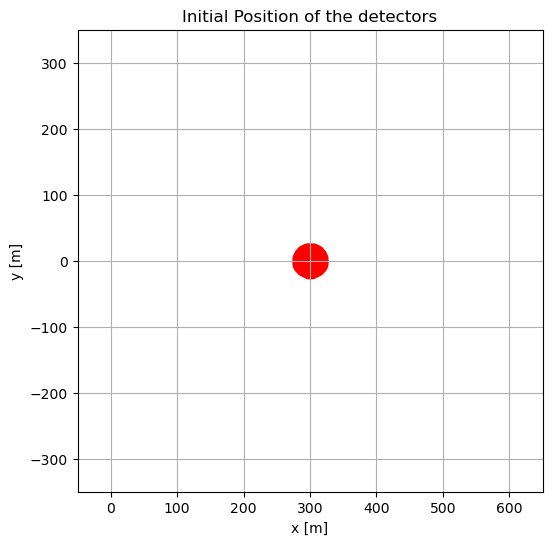

In [7]:
plt.figure(figsize=[6, 6])
plt.scatter(x_det.cpu().detach(), y_det.cpu().detach(), color="red")
plt.grid()
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Initial Position of the detectors")
plt.xlim((-50, 650))
plt.ylim((-350, 350))
plt.show()

## Generate and Visualize a Single Shower

Processing conditions 0 to 10 / 10...


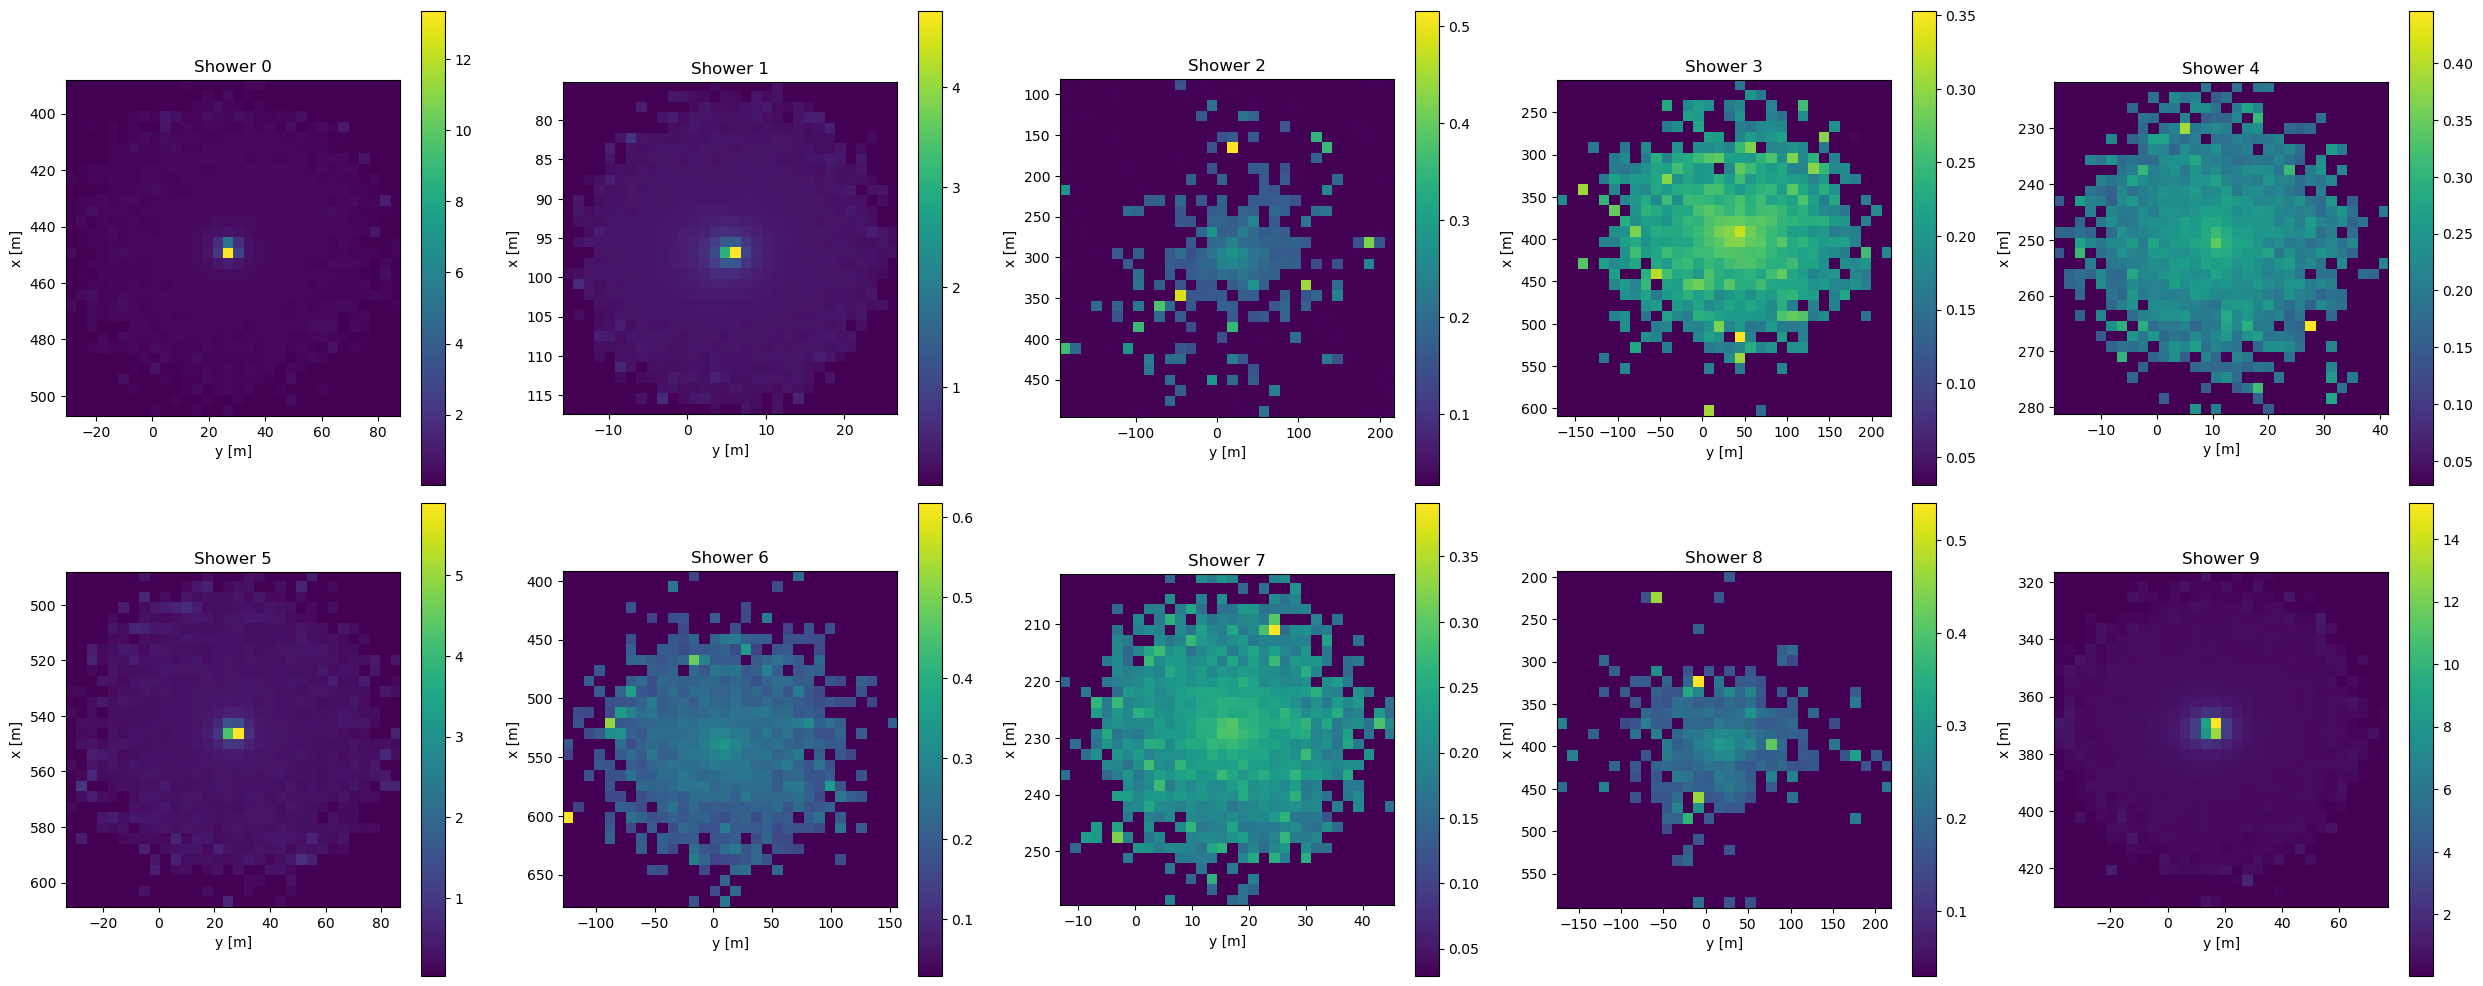

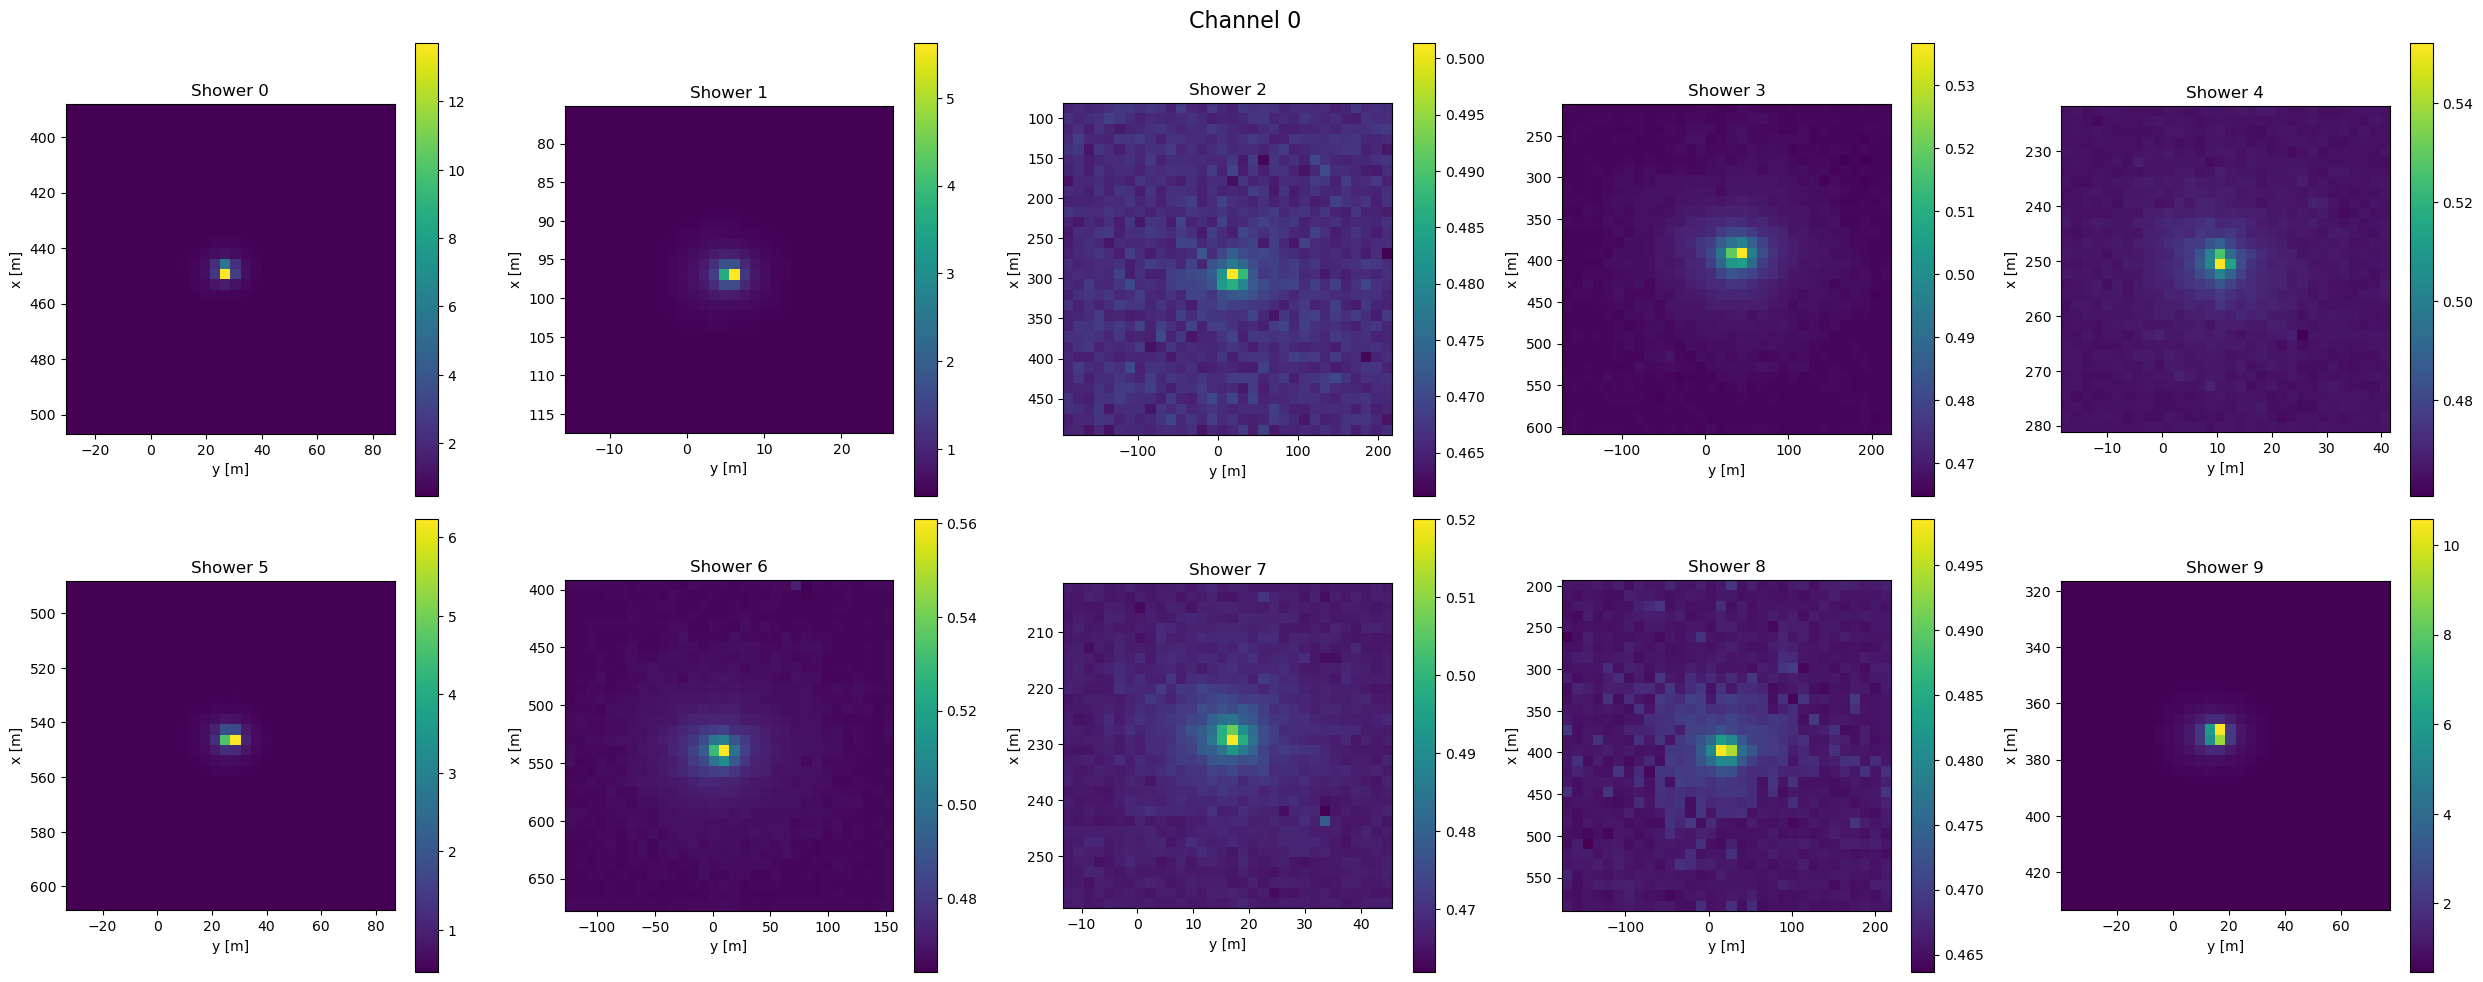

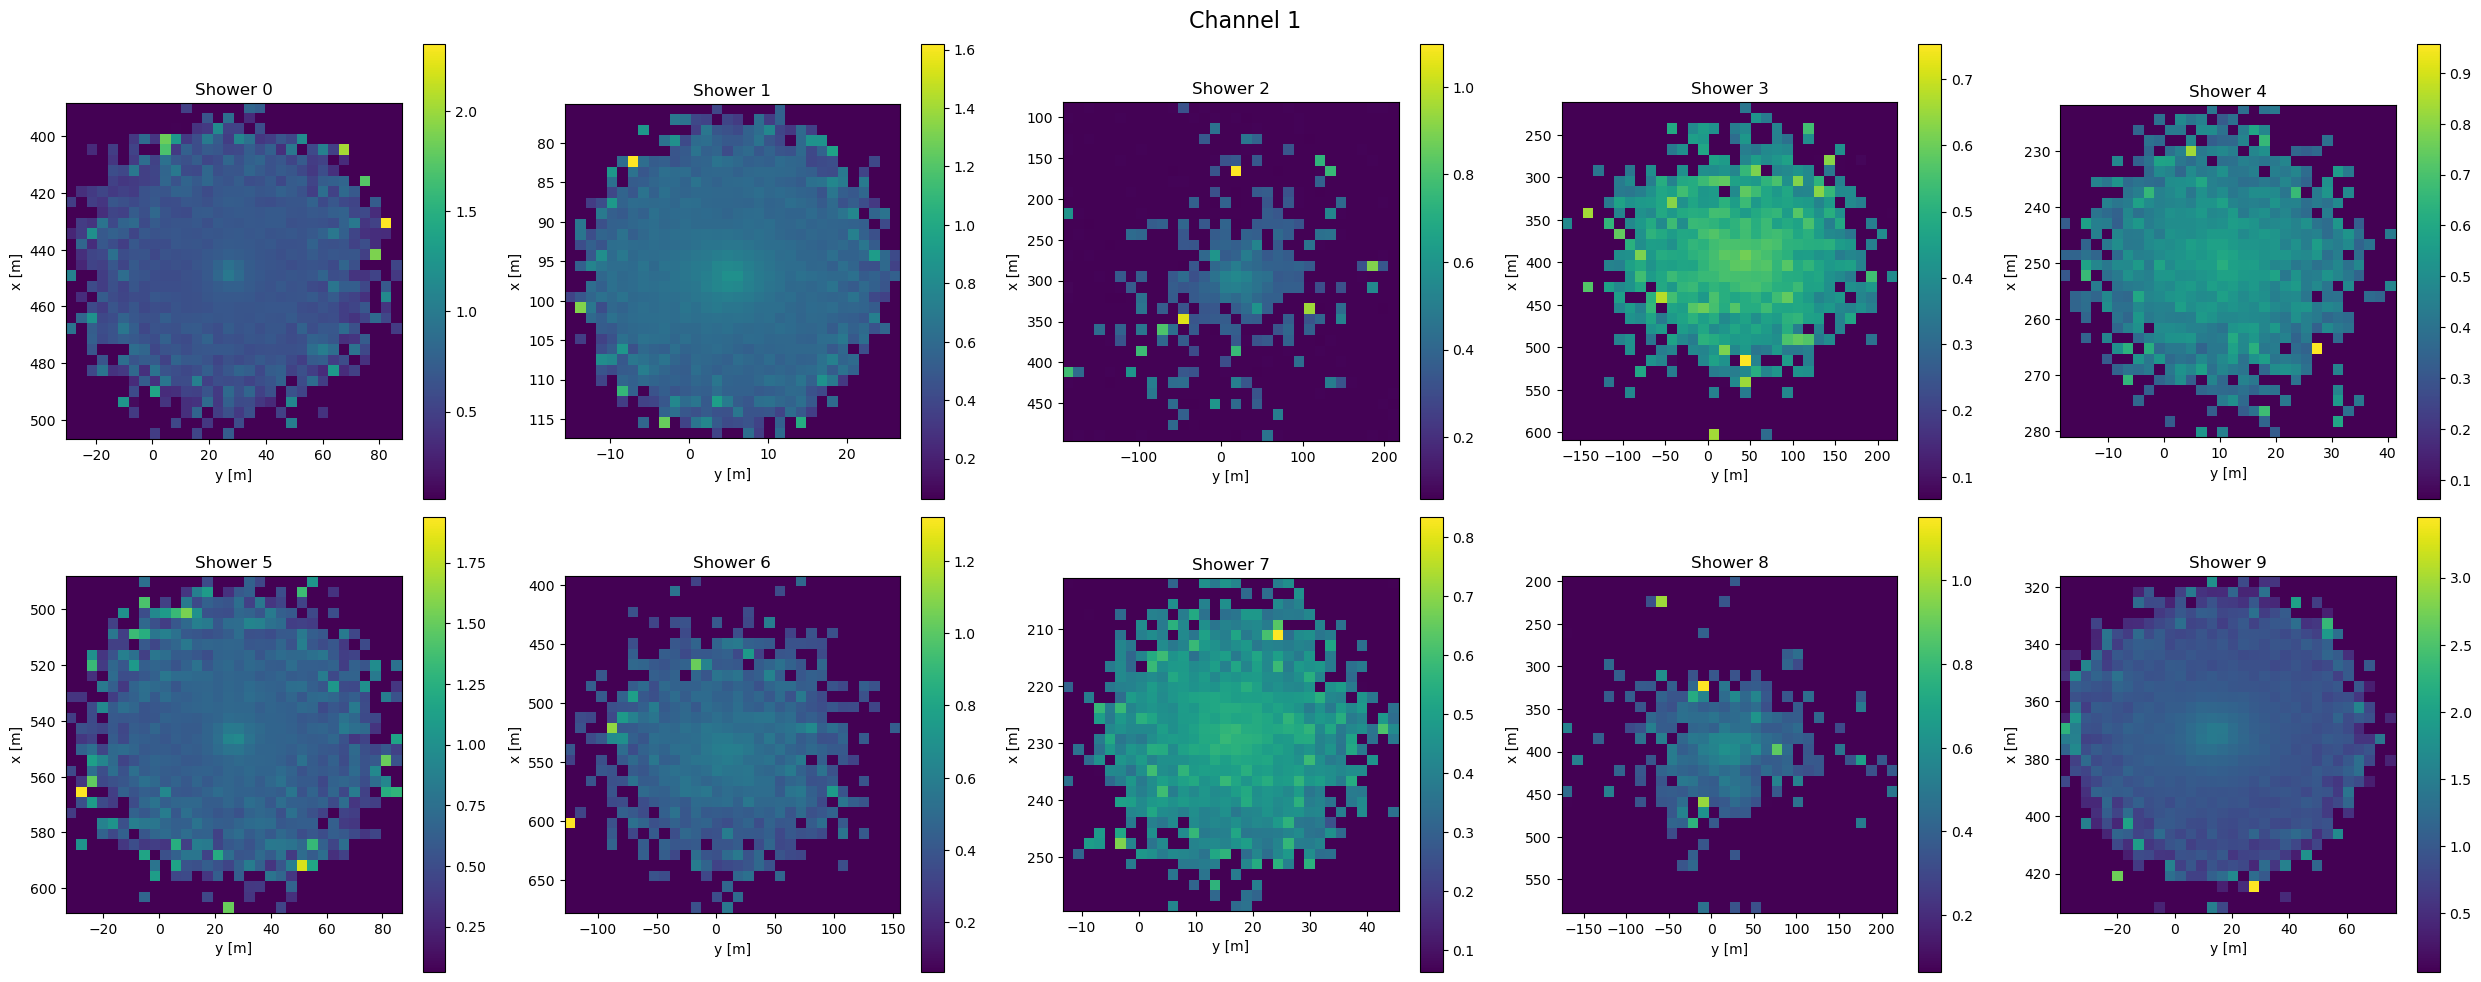

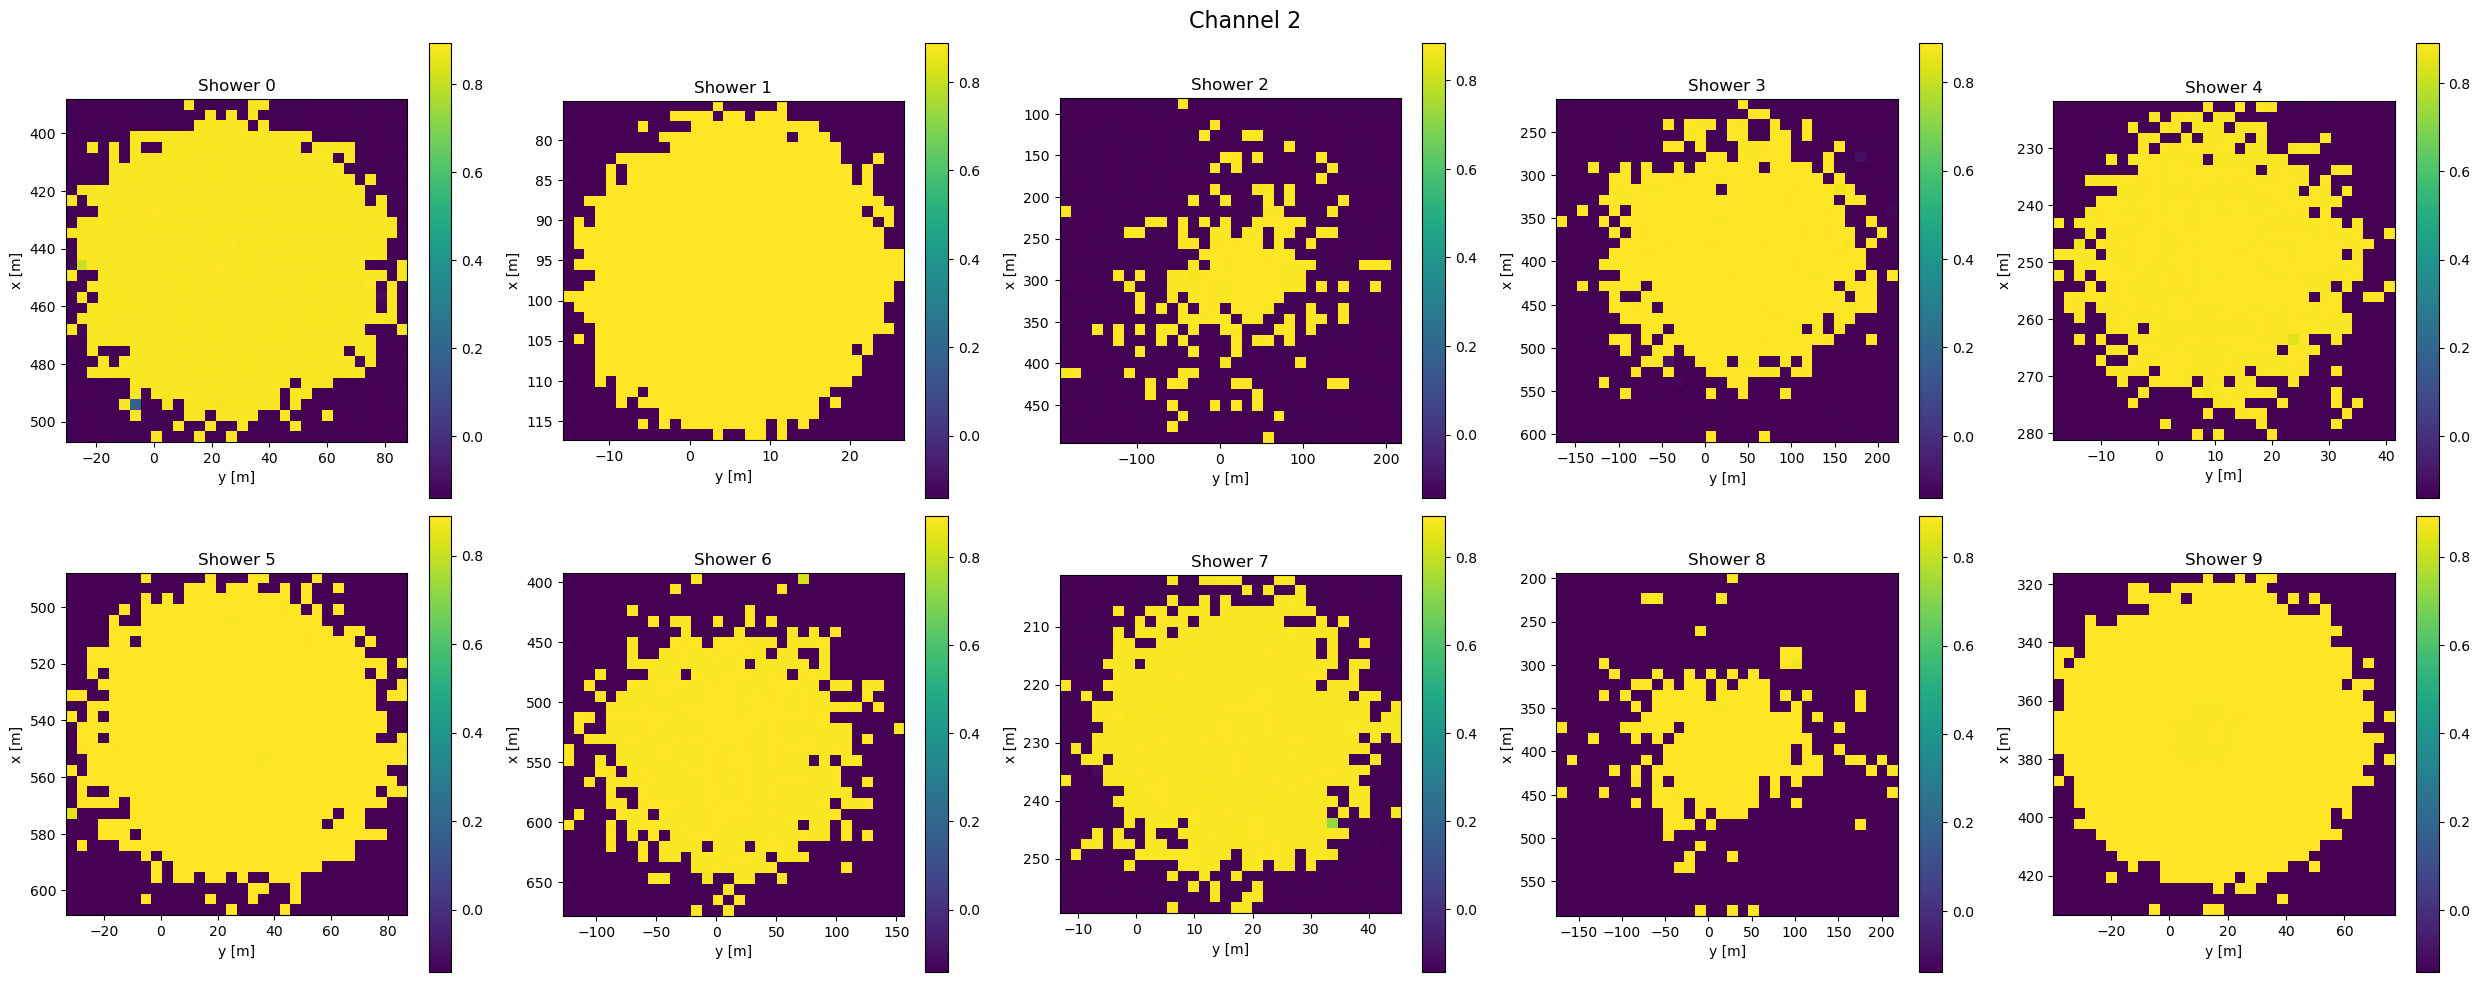

In [8]:
SWGOopt = False
with torch.no_grad():
    N, T, X0, Y0, energy, sin_z, cos_z, sin_a, cos_a = generate_showers(x_det, y_det, True, number_of_showers=10)

In [9]:
print("N:", N.shape)
print("T:", T.shape)
print("X0:", X0)
print("Y0:", Y0)
print("E:", energy.shape)

N: torch.Size([10, 500])
T: torch.Size([10, 500])
X0: 

tensor([444.8168,  96.0075, 288.7098, 392.7951, 249.6989, 544.0835, 534.1423,
        228.3350, 386.4493, 370.0512], device='cuda:0')
Y0: tensor([25.7629,  4.7147,  8.7167, 26.2423,  9.8769, 24.5193,  5.2540, 15.5426,
        11.4839, 13.2687], device='cuda:0')
E: torch.Size([10])


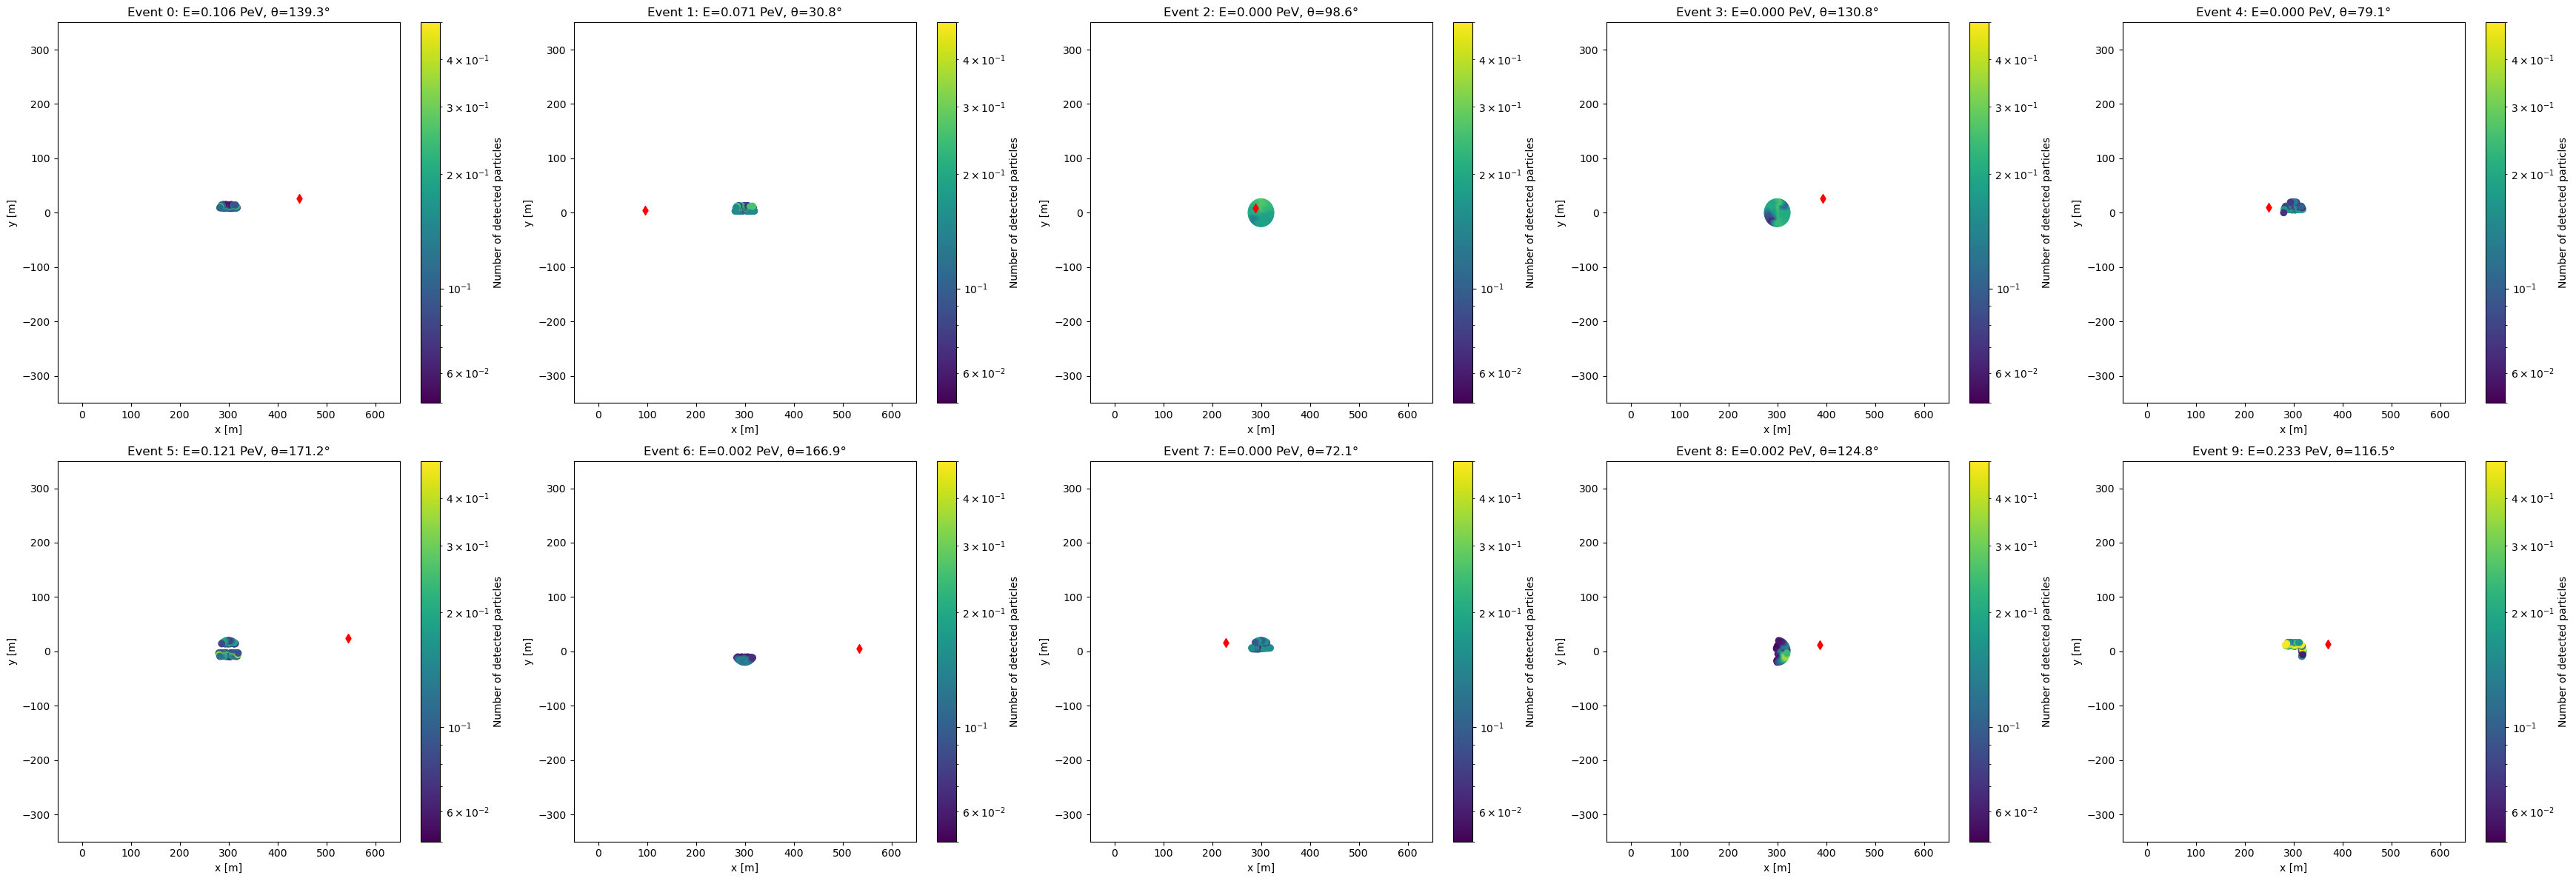

In [10]:
th = torch.atan2(sin_z, cos_z)
ph = torch.atan2(sin_a, cos_a)

n_events = N.shape[0]
ncols = 5
nrows = (n_events + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 6 * nrows))
axes  = axes.flatten()

for i in range(n_events):
    N_tmp = N[i]
    idx = torch.where(N_tmp >= 5e-2)[0]
    norm = LogNorm(vmin=5e-2, vmax=5e-1)

    scatter = axes[i].scatter(x_det[idx].detach().cpu(), y_det[idx].detach().cpu(), c=N_tmp[idx].detach().cpu(), cmap="viridis", norm=norm)
    axes[i].scatter(X0[i].item(), Y0[i].item(), c="red", marker="d")
    fig.colorbar(scatter, ax=axes[i], label='Number of detected particles')
    axes[i].set_xlabel("x [m]"); axes[i].set_ylabel("y [m]")
    axes[i].set_xlim((-50, 650)); axes[i].set_ylim((-350, 350))
    axes[i].set_title(f"Event {i}: E={energy[i].item():.3f} PeV, θ={th[i].item()*180/np.pi:.1f}°")

for i in range(n_events, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

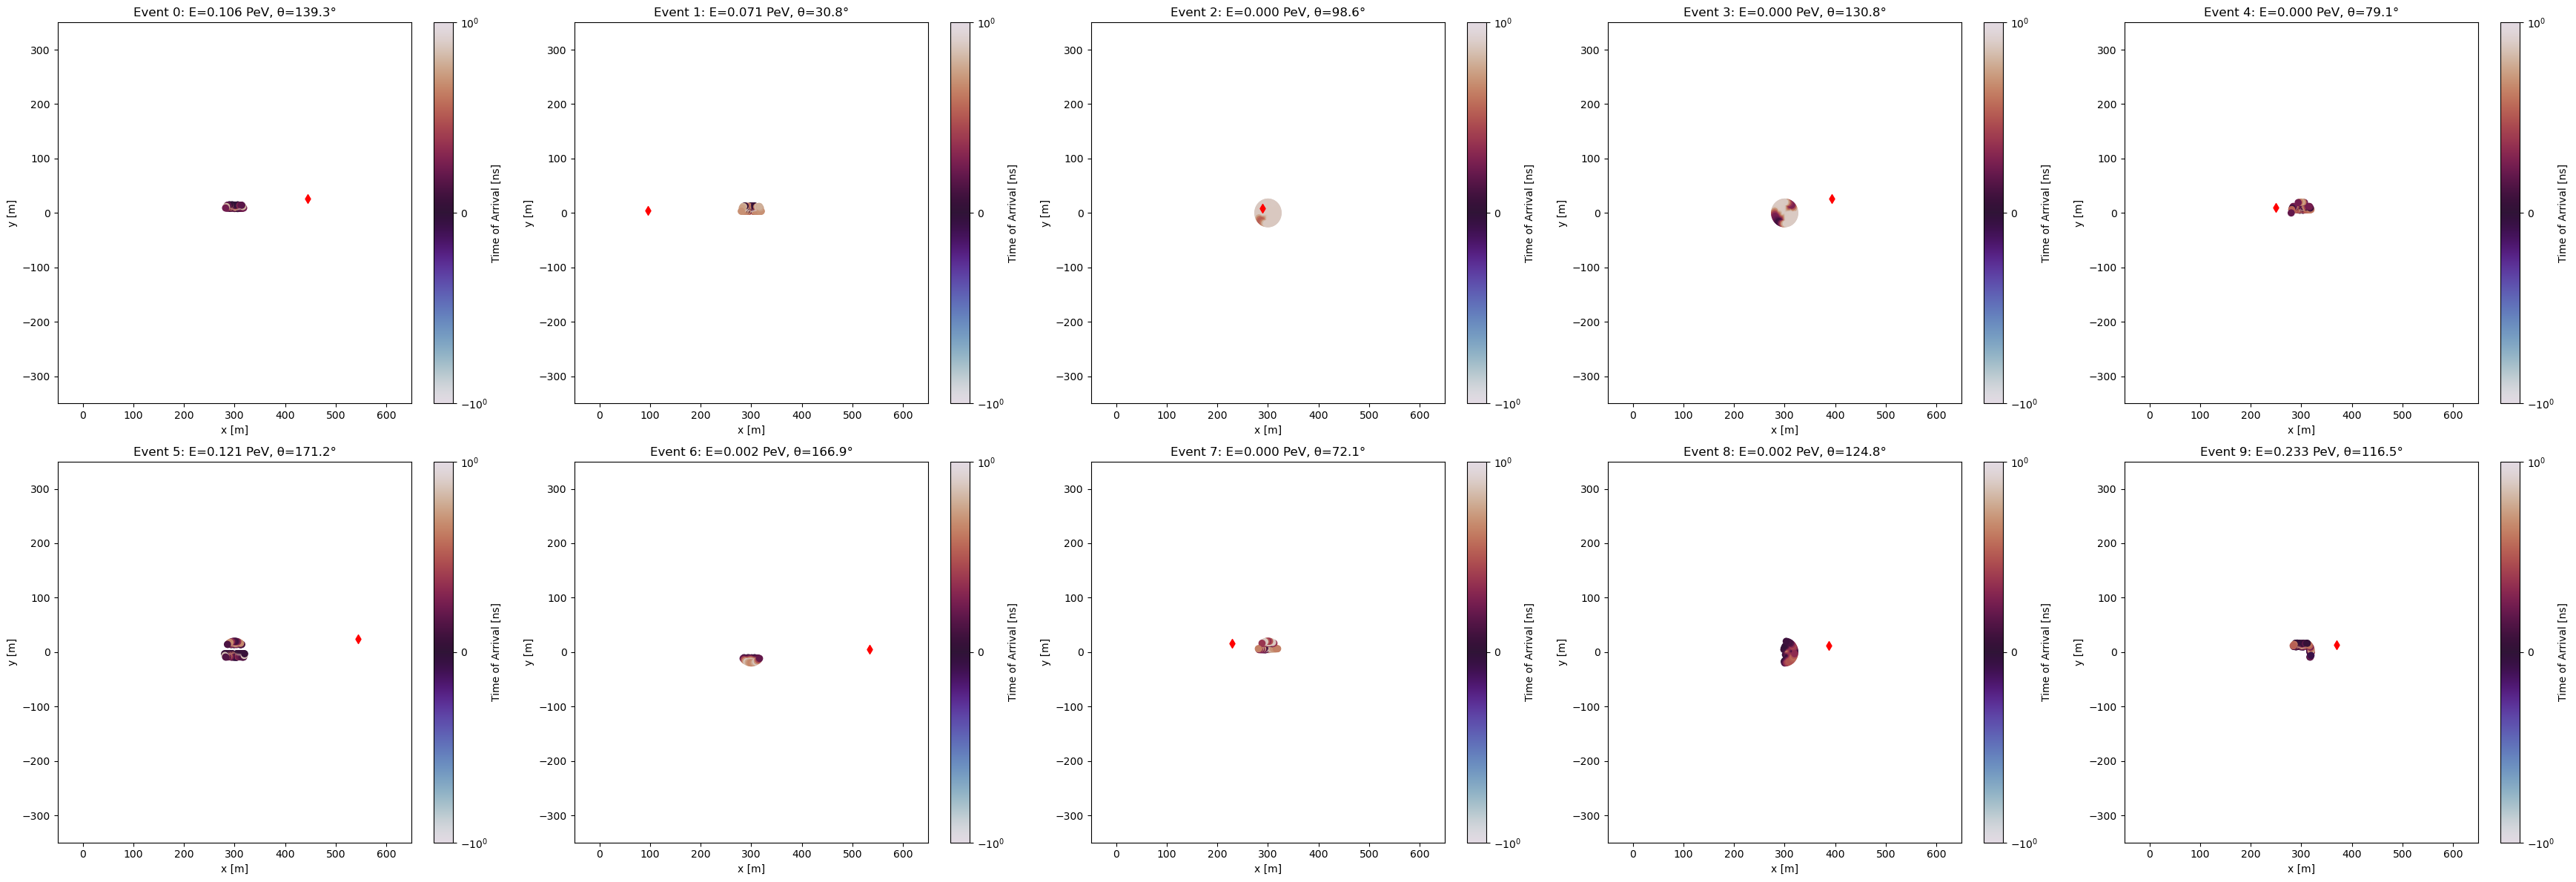

In [11]:
th = torch.atan2(sin_z, cos_z)
ph = torch.atan2(sin_a, cos_a)

n_events = N.shape[0]
ncols = 5
nrows = (n_events + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 6 * nrows))
axes  = axes.flatten()

for i in range(n_events):
    N_tmp = N[i]
    T_tmp = T[i]
    idx = torch.where(N_tmp >= 5e-2)[0]
    from matplotlib.colors import SymLogNorm
    norm = SymLogNorm(linthresh=1, vmin=-1, vmax=1)


    scatter = axes[i].scatter(x_det[idx].detach().cpu(), y_det[idx].detach().cpu(), c=T_tmp[idx].detach().cpu(), cmap="twilight", norm=norm)
    
    axes[i].scatter(X0[i].item(), Y0[i].item(), c="red", marker="d")
    fig.colorbar(scatter, ax=axes[i], label='Time of Arrival [ns]')
    axes[i].set_xlabel("x [m]"); axes[i].set_ylabel("y [m]")
    axes[i].set_xlim((-50, 650)); axes[i].set_ylim((-350, 350))
    axes[i].set_title(f"Event {i}: E={energy[i].item():.3f} PeV, θ={th[i].item()*180/np.pi:.1f}°")

for i in range(n_events, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

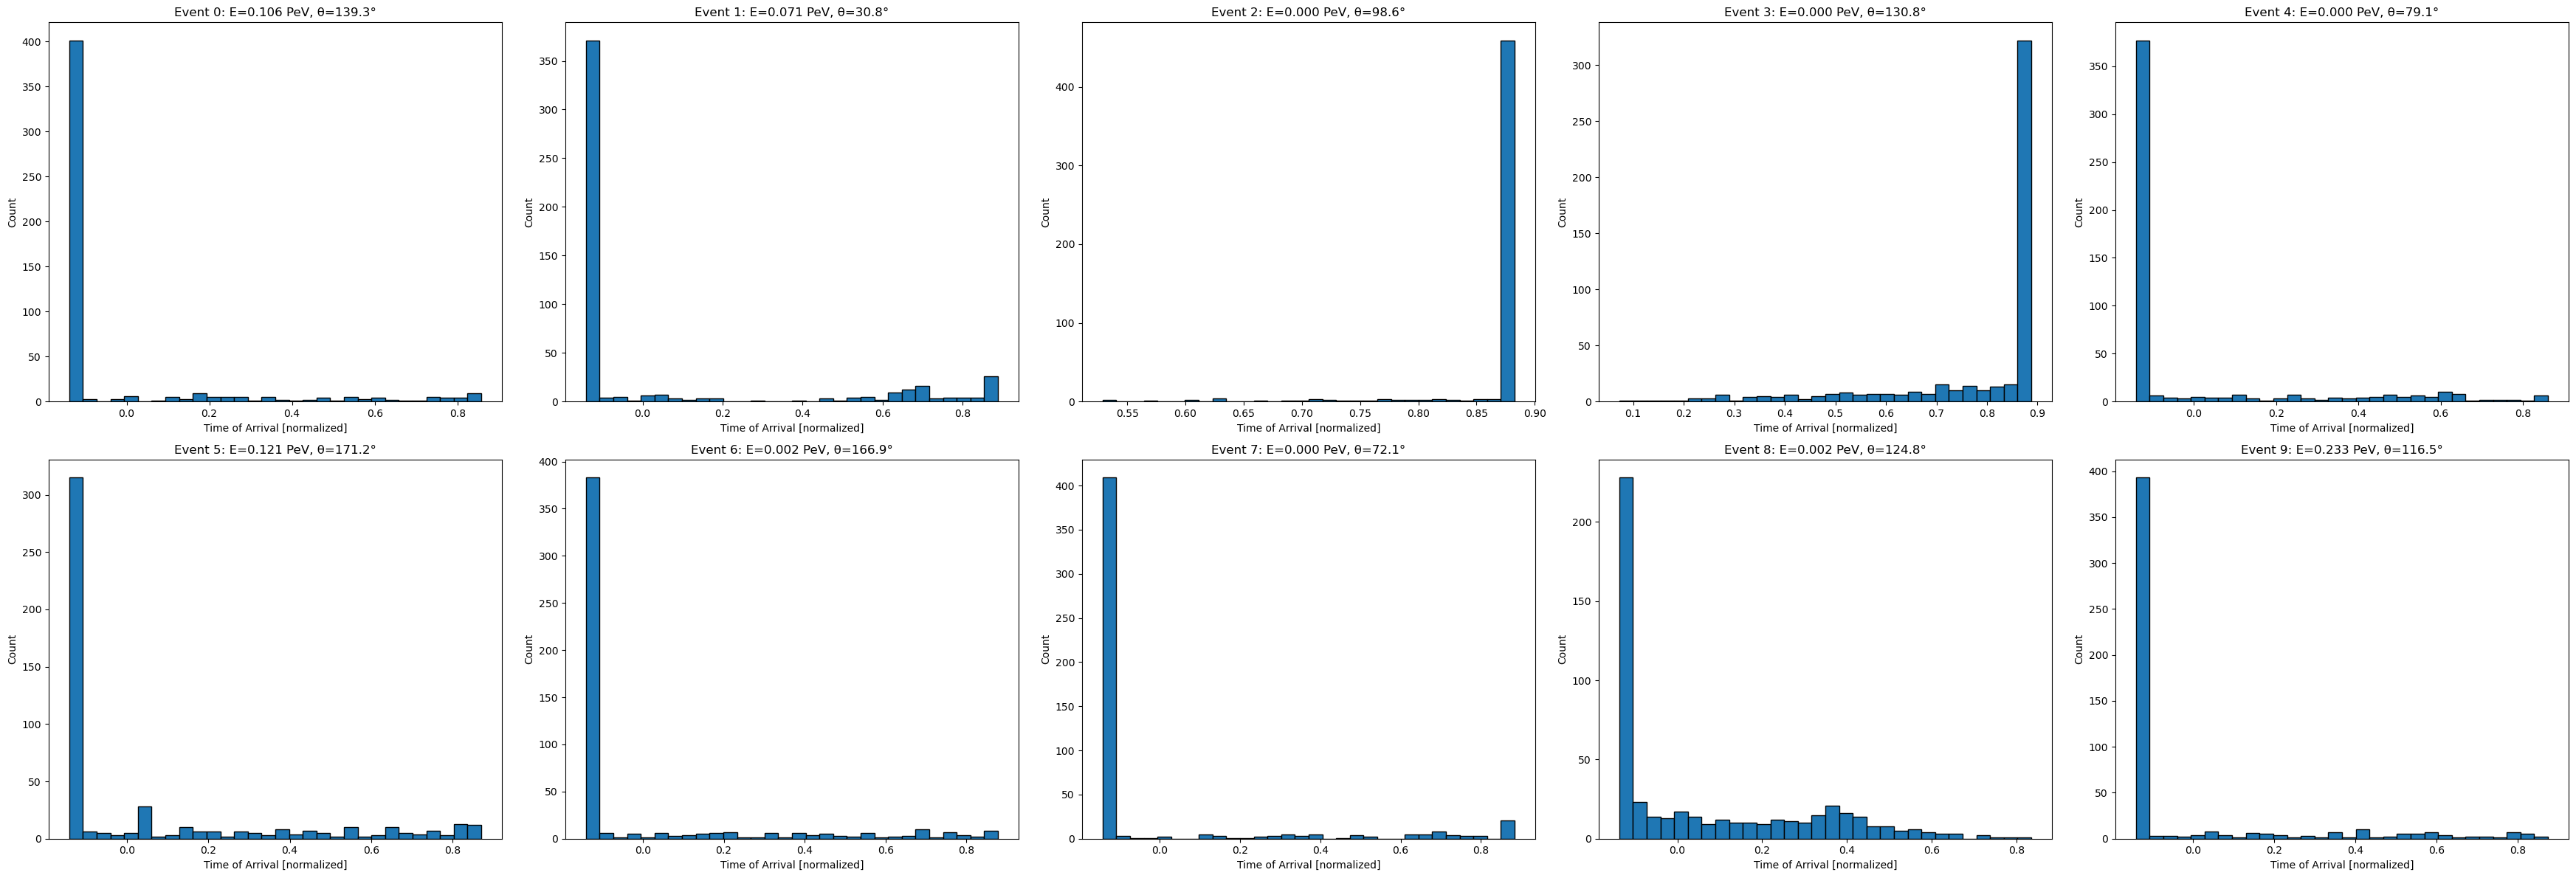

In [12]:
th = torch.atan2(sin_z, cos_z)
ph = torch.atan2(sin_a, cos_a)

n_events = N.shape[0]
ncols = 5
nrows = (n_events + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 6 * nrows))
axes = axes.flatten()

for i in range(n_events):
    N_tmp = N[i]
    T_tmp = T[i]
    idx = torch.where(N_tmp >= 5e-3)[0]
    axes[i].hist(T_tmp[idx].detach().cpu().numpy(), bins=30, edgecolor='black')
    axes[i].set_xlabel("Time of Arrival [normalized]")
    axes[i].set_ylabel("Count")
    axes[i].set_title(f"Event {i}: E={energy[i].item():.3f} PeV, θ={th[i].item()*180/np.pi:.1f}°")

for i in range(n_events, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()


## Generate Training Data

In [13]:
%%time

if generate_new_data:
    N, T, X0, Y0, energy, sin_z, cos_z, sin_a, cos_a = generate_showers(x_det, y_det, False, number_of_showers=Nevents)

    th = torch.atan2(sin_z, cos_z)
    ph = torch.atan2(sin_a, cos_a)

    E_norm, theta_norm, phi_norm = NormalizeLabels(energy, th, ph)
    x0 = X0 / 5000
    y0 = Y0 / 5000

    x_det_exp = x_det.unsqueeze(0).expand(Nevents, -1)
    y_det_exp = y_det.unsqueeze(0).expand(Nevents, -1)

    x0_exp = x0.unsqueeze(1).expand(-1, Nunits)
    y0_exp = y0.unsqueeze(1).expand(-1, Nunits)

    inputs = torch.stack([x_det_exp, y_det_exp, N, T, x0_exp, y0_exp], dim=2).float()
    labels = torch.stack([E_norm, theta_norm, phi_norm], dim=1).float()

    os.makedirs(output_dir, exist_ok=True)
    torch.save(inputs, f"{output_dir}/inputs.pt")
    torch.save(labels, f"{output_dir}/labels.pt")

Processing conditions 0 to 5000 / 20000...


Processing conditions 5000 to 10000 / 20000...


Processing conditions 10000 to 15000 / 20000...


Processing conditions 15000 to 20000 / 20000...


CPU times: user 12min 38s, sys: 14min 27s, total: 27min 6s
Wall time: 27min 11s


## Generate Validation Data

In [14]:
%%time

if generate_new_data:
    N, T, X0, Y0, energy, sin_z, cos_z, sin_a, cos_a = generate_showers(x_det, y_det, False, number_of_showers=Nvalidation)

    th = torch.atan2(sin_z, cos_z)
    ph = torch.atan2(sin_a, cos_a)

    E_norm, theta_norm, phi_norm = NormalizeLabels(energy, th, ph)
    x0 = X0 / 5000
    y0 = Y0 / 5000

    x_det_exp = x_det.unsqueeze(0).expand(Nvalidation, -1)
    y_det_exp = y_det.unsqueeze(0).expand(Nvalidation, -1)

    x0_exp = x0.unsqueeze(1).expand(-1, Nunits)
    y0_exp = y0.unsqueeze(1).expand(-1, Nunits)

    inputs_val = torch.stack([x_det_exp, y_det_exp, N, T, x0_exp, y0_exp], dim=2).float()
    labels_val = torch.stack([E_norm, theta_norm, phi_norm], dim=1).float()

    torch.save(inputs_val, f"{output_dir}/inputs_val.pt")
    torch.save(labels_val, f"{output_dir}/labels_val.pt")

Processing conditions 0 to 2000 / 2000...


CPU times: user 1min 16s, sys: 1min 27s, total: 2min 44s
Wall time: 2min 45s


## Generate Test Data

In [15]:
if generate_new_data:
    N, T, X0, Y0, energy, sin_z, cos_z, sin_a, cos_a = generate_showers(x_det, y_det, False, number_of_showers=Ntest)

    th = torch.atan2(sin_z, cos_z)
    ph = torch.atan2(sin_a, cos_a)

    E_norm, theta_norm, phi_norm = NormalizeLabels(energy, th, ph)
    x0 = X0 / 5000
    y0 = Y0 / 5000

    x_det_exp = x_det.unsqueeze(0).expand(Ntest, -1)
    y_det_exp = y_det.unsqueeze(0).expand(Ntest, -1)


    x0_exp = x0.unsqueeze(1).expand(-1, Nunits)
    y0_exp = y0.unsqueeze(1).expand(-1, Nunits)

    inputs_test = torch.stack([x_det_exp, y_det_exp, N, T, x0_exp, y0_exp], dim=2).float()
    labels_test = torch.stack([E_norm, theta_norm, phi_norm], dim=1).float()

    torch.save(inputs_test, f"{output_dir}/inputs_test.pt")
    torch.save(labels_test, f"{output_dir}/labels_test.pt")

Processing conditions 0 to 300 / 300...


## Load Cached Data (optional)

In [16]:
inputs = torch.load(f"{output_dir}/inputs.pt")
labels = torch.load(f"{output_dir}/labels.pt")
inputs_val = torch.load(f"{output_dir}/inputs_val.pt")
labels_val = torch.load(f"{output_dir}/labels_val.pt")
inputs_test = torch.load(f"{output_dir}/inputs_test.pt")
labels_test = torch.load(f"{output_dir}/labels_test.pt")

In [17]:
# # switch normaliation value

# labels_denorm = DenormalizeLabels(labels[:,0], labels[:,1], labels[:,2], theta_max = torch.pi*65/180)
# labels_renorm = NormalizeLabels(labels_denorm[0], labels_denorm[1], labels_denorm[2])
# labels_renorm = torch.stack(labels_renorm, dim=1)

# labels_val_denorm = DenormalizeLabels(labels_val[:,0], labels_val[:,1], labels_val[:,2], theta_max = torch.pi*65/180)
# labels_val_renorm = NormalizeLabels(labels_val_denorm[0], labels_val_denorm[1], labels_val_denorm[2])
# labels_val_renorm = torch.stack(labels_val_renorm, dim=1)


# labels_test_denorm = DenormalizeLabels(labels_test[:,0], labels_test[:,1], labels_test[:,2], theta_max = torch.pi*65/180)
# labels_test_renorm = NormalizeLabels(labels_test_denorm[0], labels_test_denorm[1], labels_test_denorm[2])
# labels_test_renorm = torch.stack(labels_test_renorm, dim=1)

# # labels_renorm.shape, labels_val_renorm.shape, labels_test_renorm.shape

# torch.save(labels_renorm, f"{output_dir}/labels.pt")
# torch.save(labels_val_renorm, f"{output_dir}/labels_val.pt")
# torch.save(labels_test_renorm, f"{output_dir}/labels_test.pt")

In [18]:
# # EDA
# import seaborn as sns
# # Particle count (N) summaries per event
# N_total  = inputs[:, :, 2].sum(dim=1)
# N_mean   = inputs[:, :, 2].mean(dim=1)
# N_median = inputs[:, :, 2].median(dim=1).values
# N_max    = inputs[:, :, 2].max(dim=1).values
# N_std    = inputs[:, :, 2].std(dim=1)

# # Arrival time (T) summaries per event
# T_mean   = inputs[:, :, 3].mean(dim=1)
# T_median = inputs[:, :, 3].median(dim=1).values
# T_max    = inputs[:, :, 3].max(dim=1).values
# T_min    = inputs[:, :, 3].min(dim=1).values
# T_std    = inputs[:, :, 3].std(dim=1)

# df = pd.DataFrame({
#     'N_total':  N_total.cpu().numpy(),
#     'N_mean':   N_mean.cpu().numpy(),
#     'N_median': N_median.cpu().numpy(),
#     'N_max':    N_max.cpu().numpy(),
#     'N_std':    N_std.cpu().numpy(),
#     'T_mean':   T_mean.cpu().numpy(),
#     'T_median': T_median.cpu().numpy(),
#     'T_max':    T_max.cpu().numpy(),
#     'T_min':    T_min.cpu().numpy(),
#     'T_std':    T_std.cpu().numpy(),
#     'x0':       labels[:, 0].cpu().numpy(),
#     'y0':       labels[:, 1].cpu().numpy(),
#     'E_norm':   labels[:, 2].cpu().numpy(),
#     'theta':    labels[:, 3].cpu().numpy(),
#     'phi':      labels[:, 4].cpu().numpy(),
# })

# sns.pairplot(df.sample(2000))


## Train Reconstruction NN

In [19]:
model = Reconstruction(num_detectors=Nunits).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=3e-5)

In [20]:
# Per-feature normalization stats (computed from training data only)
input_mean = inputs.mean(dim=(0, 1))  # [6]
input_std  = inputs.std(dim=(0, 1))   # [6]
input_std[input_std < 1e-8] = 1.0

# Normalize cached datasets
inputs     = (inputs - input_mean) / input_std
inputs_val = (inputs_val - input_mean) / input_std
inputs_test = (inputs_test - input_mean) / input_std

dataset = TensorDataset(inputs, labels)
dataloader = DataLoader(dataset, batch_size=256, shuffle=True, drop_last=False, num_workers=0)

Training is 10% done, with Loss = 0.09


Training is 20% done, with Loss = 0.09


Training is 30% done, with Loss = 0.09


Training is 40% done, with Loss = 0.10


Training is 50% done, with Loss = 0.10


Training is 60% done, with Loss = 0.10


Training is 70% done, with Loss = 0.11


Training is 80% done, with Loss = 0.11


Training is 90% done, with Loss = 0.11


Training is 100% done, with Loss = 0.11
CPU times: user 2min 30s, sys: 745 ms, total: 2min 31s
Wall time: 2min 33s


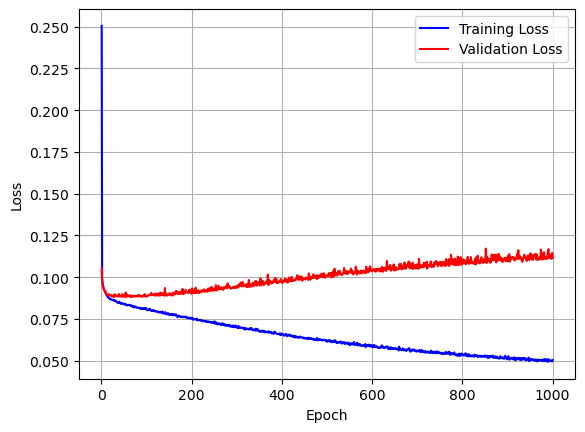

In [21]:
%%time
if generate_new_data:
    val_losses = []
    losses = []
    early_stopper = EarlyStopping()

    for num_epoch in range(1000):
        epoch_loss = 0
        total_batch = 0
        
        for batch_inputs, batch_labels in dataloader:
            train_x = batch_inputs.flatten(start_dim=1, end_dim=2).to(device)
            train_y = batch_labels.to(device)
            
            outputs = model(train_x)
            loss = criterion(outputs, train_y)
            epoch_loss += loss.item()
            total_batch += 1

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        val_x = inputs_val.flatten(start_dim=1, end_dim=2).to(device)
        val_y = labels_val.to(device)

        model.eval()
        with torch.no_grad():
            val_output = model(val_x)
            val_loss = criterion(val_output, val_y)
        
        val_losses.append(val_loss.item())
        early_stopper(val_loss)

        if (num_epoch + 1) % 100 == 0:
            print(f"Training is {int((num_epoch + 1) / 10)}% done, with Loss = {val_loss:.2f}")

        losses.append(epoch_loss / total_batch)

    plt.plot(np.arange(1, len(losses) + 1), losses, color="blue", label="Training Loss")
    plt.plot(np.arange(1, len(val_losses) + 1), val_losses, color="red", label="Validation Loss")
    plt.legend(); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.grid()

    torch.save(model.state_dict(), f"{output_dir}/model_weights.pth")


## Evaluate Reconstruction

In [22]:
model.load_state_dict(torch.load(f"{output_dir}/model_weights.pth"))

model.eval()
with torch.no_grad():
    outputs = model(inputs_test.view(Ntest, -1).to(device)).cpu()

In [23]:

# x_pred = outputs[:, 0]
# y_pred = outputs[:, 1]
E_pred, theta_pred, phi_pred = DenormalizeLabels(outputs[:, 0], outputs[:, 1], outputs[:, 2])
E_lb, theta_lb, phi_lb = DenormalizeLabels(labels_test[:, 0], labels_test[:, 1], labels_test[:, 2])

E_p,    E_r     =   E_pred,       E_lb
Th_p,   Th_r    =   theta_pred,   theta_lb
Ph_p,   Ph_r    =   phi_pred,     phi_lb

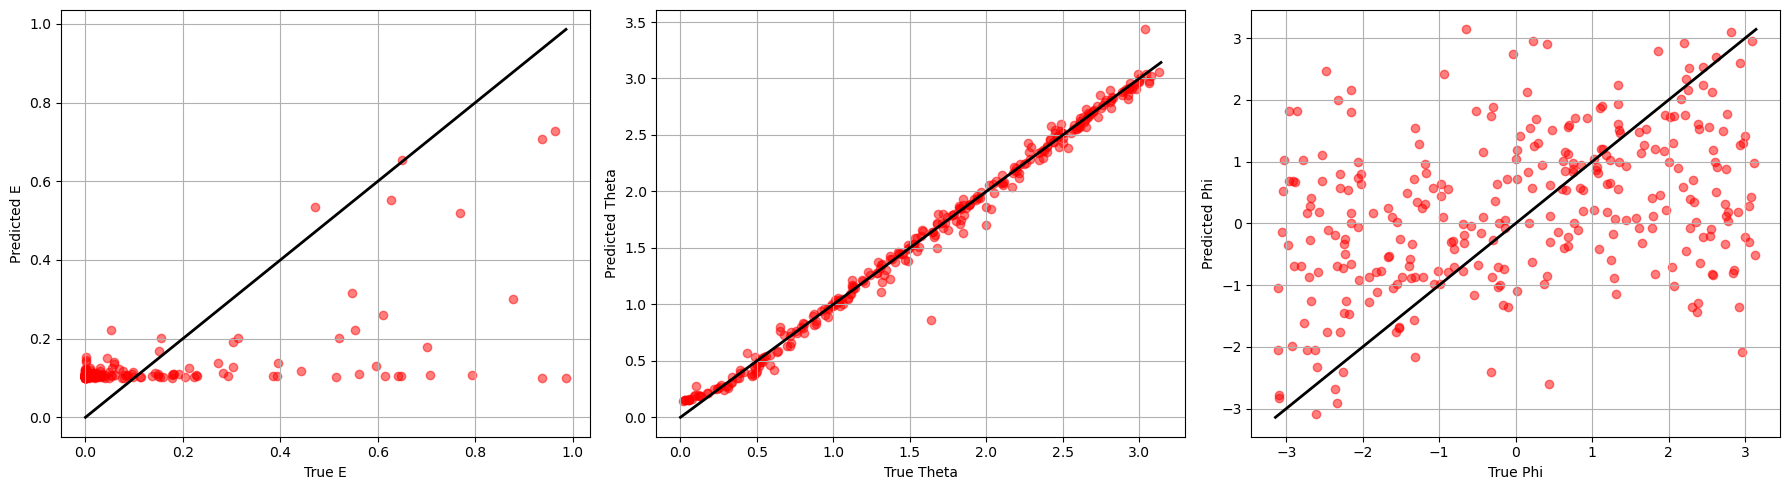

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(E_r.cpu(), E_p.cpu(), alpha=.5, color="r")
axes[0].plot([0, E_r.max().cpu()], [0, E_r.max().cpu()], "k-", lw=2)
axes[0].set_xlabel("True E"); axes[0].set_ylabel("Predicted E"); axes[0].grid()

axes[1].scatter(Th_r.cpu(), Th_p.detach().cpu(), alpha=.5, color="r")
axes[1].plot([0, np.pi], [0, np.pi], "k-", lw=2)
axes[1].set_xlabel("True Theta"); axes[1].set_ylabel("Predicted Theta"); axes[1].grid()

axes[2].scatter(Ph_r.cpu(), Ph_p.detach().cpu(), alpha=.5, color="r")
axes[2].plot([-np.pi, np.pi], [-np.pi, np.pi], "k-", lw=2)
axes[2].set_xlabel("True Phi"); axes[2].set_ylabel("Predicted Phi"); axes[2].grid()

plt.tight_layout(); plt.show()


## Load/Initialize Model for Optimization

In [25]:
torch.save(model.state_dict(), f"{output_dir}/model_weights.pth")

model = Reconstruction(num_detectors=Nunits).to(device)

path = Path(f"{output_dir}/checkpoint.pth")
if path.exists():
    checkpoint = torch.load(f"{output_dir}/checkpoint.pth")
    model.load_state_dict(checkpoint['model_state_dict'])
    print("Updated Weights are loaded")
else:
    model.load_state_dict(torch.load(f"{output_dir}/model_weights.pth"))
    print("Initial Weights are loaded")

Initial Weights are loaded


## Initialize Learnable Layout

In [26]:
e = 0
os.makedirs(f"{output_dir}/Python_Layout", exist_ok=True)

for i in range(1000):
    p_layout = Path(f"{output_dir}/Python_Layout/Layout_{i + 1}.txt")
    if p_layout.exists():
        data = np.loadtxt(p_layout)
        x_det = torch.tensor(data[:, 0], dtype=torch.float32)
        y_det = torch.tensor(data[:, 1], dtype=torch.float32)
        e = i + 1

if e > 0:
    print(f"Updated Layout {e} is initialized")
else:
    print("First Layout is initialized")

xy_module = LearnableXY(x_det, y_det, device=device)

First Layout is initialized


## Layout Optimization Loop

In [27]:
input_std = input_std.to(device)
input_mean = input_mean.to(device)

In [28]:
%%time

SWGOopt = True
optimizer = torch.optim.SGD(xy_module.parameters(), lr=1, momentum=.9)

if path.exists():
    checkpoint = torch.load(path)
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    num_epoch = checkpoint.get("epoch") + 1
    loss = checkpoint.get("loss")
    print(f"Optimizer is initialized from the last epoch {num_epoch}")
else:
    num_epoch = 0
    print("Optimizer is initialized")

# max_grad = 5. #10.
Nbatch = 500#1000

if num_epoch < 20:
    Nfinetune = 1250#2500
elif num_epoch >= 20:
    Nfinetune = 2500#5000

U_vals = []
U_th_vals = []
U_phi_vals = []
U_e_vals = []
U_pr_vals = []

for epoch in range(num_epoch, num_epoch + 100):
    x_det_opt, y_det_opt = xy_module()
    
    N_list, T_list, X0, Y0, energy, sin_z, cos_z, sin_a, cos_a = generate_showers(x_det_opt, y_det_opt, False, number_of_showers=Nbatch)
    
    th = torch.atan2(sin_z, cos_z).to(device)
    ph = torch.atan2(sin_a, cos_a).to(device)

    X0 /= 5000
    Y0 /= 5000
    
    # detector locations            
    x_det_opt_exp = x_det_opt.unsqueeze(0).repeat(Nbatch, 1)
    y_det_opt_exp = y_det_opt.unsqueeze(0).repeat(Nbatch, 1)

    # shower centers    
    x0_exp = X0.unsqueeze(1).expand(-1, Nunits)
    y0_exp = Y0.unsqueeze(1).expand(-1, Nunits)

    inputs_batch = torch.stack([x_det_opt_exp, y_det_opt_exp, N_list, T_list, x0_exp, y0_exp], dim=2).float()
    with torch.no_grad():
        input_mean[0] = inputs_batch[:, :, 0].mean()
        input_mean[1] = inputs_batch[:, :, 1].mean()
        input_std[0]  = inputs_batch[:, :, 0].std().clamp(min=1e-8)
        input_std[1]  = inputs_batch[:, :, 1].std().clamp(min=1e-8)

    inputs_batch_norm = (inputs_batch - input_mean) / input_std

    model.eval()
    preds_batch = model(inputs_batch_norm.view(Nbatch, -1))

    preds_e, preds_th, preds_phi = DenormalizeLabels(preds_batch[:, 0], preds_batch[:, 1], preds_batch[:, 2])

    # compute utility 
    r_score = reconstructability(inputs_batch[:, :, 2])
    U = (
        1e2    *   U_angle( preds_th, th, r_score ) + 
        1e2    *   U_angle( preds_phi, ph, r_score ) +
        # 1e3     *   U_E( preds_e, energy, r_score ) + 
        5e5     *   U_PR( r_score ) 
    ) / 1e5

    # save utlity values for logging
    U_vals.append( U.item() )
    U_th_vals.append( 1e2 * U_angle( preds_th, th, r_score ).item() )
    U_phi_vals.append( 1e2 * U_angle( preds_phi, ph, r_score ).item() )
    U_e_vals.append( 1e3 * U_E( preds_e, energy, r_score ).item() )
    U_pr_vals.append( ( 5e5 * U_PR( r_score ) ).item() )

    print(f"Utility: {U:.2f}")

    # backpropagate loss
    Loss = -U
    Loss.backward()

    for name, p in xy_module.named_parameters():
        print(f"{name}: grad norm = {p.grad.norm().item() if p.grad is not None else 'None'}")

    # torch.nn.utils.clip_grad_norm_(xy_module.parameters(), max_norm=max_grad)
    optimizer.step()

    with torch.no_grad():
        push_apart(xy_module, min_dist=2 * TankRadius)
    
    optimizer.zero_grad()
    
    # Fine-tune NN every 5 epochs
    if (epoch + 1) % 5 == 0:
        
        model.zero_grad()
        print(f"Fine Tune at epoch {epoch + 1}")
        
        # Prepare data
        with torch.no_grad():
            x_det_ft, y_det_ft = xy_module()
            x_ft = x_det_ft.detach()
            y_ft = y_det_ft.detach()

            N, T, X0, Y0, energy, sin_z, cos_z, sin_a, cos_a = generate_showers(x_ft, y_ft, False, number_of_showers=Nfinetune)
            
            theta = torch.atan2(sin_z, cos_z)
            phi = torch.atan2(sin_a, cos_a)
            
            energy_norm, theta_norm, phi_norm = NormalizeLabels(energy, theta, phi)
            X0 /= 5000
            Y0 /= 5000
            
            # normalized labels
            labels_finetune = torch.stack([ energy_norm, theta_norm, phi_norm], dim=1).float()
            
            # detector locations
            x_det_ft_exp = x_ft.unsqueeze(0).expand(Nfinetune, -1)
            y_det_ft_exp = y_ft.unsqueeze(0).expand(Nfinetune, -1)
            
            # shower centers
            x0_exp = X0.unsqueeze(1).expand(-1, Nunits)
            y0_exp = Y0.unsqueeze(1).expand(-1, Nunits)

            inputs_finetune = torch.stack([x_det_ft_exp, y_det_ft_exp, N, T, x0_exp, y0_exp], dim=2).float()
            
            input_mean[0] = inputs_finetune[:, :, 0].mean()
            input_mean[1] = inputs_finetune[:, :, 1].mean()
            input_std[0]  = inputs_finetune[:, :, 0].std().clamp(min=1e-8)
            input_std[1]  = inputs_finetune[:, :, 1].std().clamp(min=1e-8)

            inputs_finetune = (inputs_finetune - input_mean) / input_std

        # get model
        ReconstructionNN = model
        ReconstructionNN.train()
        criterion = nn.MSELoss()
        optimizerNN = torch.optim.Adam(ReconstructionNN.parameters(), lr=1e-6)
        
        # create training dataset
        ft_dataset = TensorDataset(inputs_finetune, labels_finetune)
        ft_dataloader = DataLoader(ft_dataset, batch_size=32, shuffle=True, drop_last=True, num_workers=0)

        # train NN for 5 sub-epochs
        for j in range(2):
            for inputs_ft, labels_ft in ft_dataloader:
                batch_size = inputs_ft.size(0)
                train_x = inputs_ft.view(batch_size, -1).to(device)
                train_y = labels_ft.view(batch_size, 3).to(device)
                outputs = ReconstructionNN(train_x)
                lossT = criterion(outputs, train_y)
                lossT.backward()
                optimizerNN.step()
                optimizerNN.zero_grad()

    torch.save({"epoch": epoch, "loss": Loss.cpu(), "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict()}, f"{output_dir}/checkpoint.pth")
    
    np.savetxt(f"{output_dir}/Python_Layout/Layout_{epoch + 1}.txt",
               np.column_stack((x_det_opt.detach().cpu().numpy(), y_det_opt.detach().cpu().numpy())))

Optimizer is initialized
Processing conditions 0 to 500 / 500...


Utility: 371.59


x: grad norm = 3.0360045433044434
y: grad norm = 33.14965057373047


Processing conditions 0 to 500 / 500...


Utility: 172.62
x: grad norm = 5.554262638092041
y: grad norm = 9.49341106414795


...

Utility: 195.85
x: grad norm = 11.567052841186523
y: grad norm = 8.349245071411133
Processing conditions 0 to 500 / 500...


Utility: 210.21
x: grad norm = 9.341755867004395
y: grad norm = 7.824095249176025
Processing conditions 0 to 500 / 500...


Utility: 208.13
x: grad norm = 5.37918758392334
y: grad norm = 7.077584743499756
Processing conditions 0 to 500 / 500...


Utility: 206.28
x: grad norm = 6.193713188171387
y: grad norm = 9.409904479980469
Fine Tune at epoch 100
Processing conditions 0 to 1250 / 1250...


CPU times: user 57min 55s, sys: 50min 34s, total: 1h 48min 30s
Wall time: 1h 48min 57s


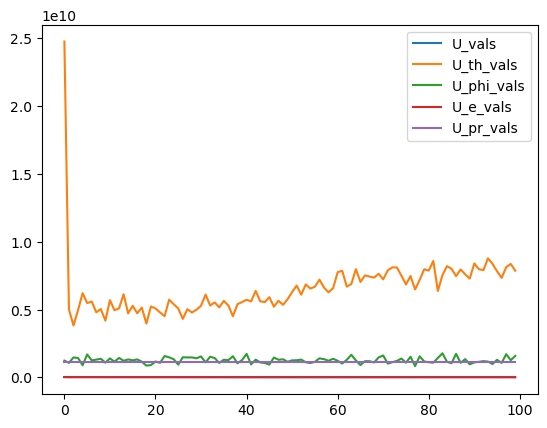

In [29]:
plt.plot(U_vals, label='U_vals')
plt.plot([1000*u for u in U_th_vals], label='U_th_vals')
plt.plot([1000*u for u in U_phi_vals], label='U_phi_vals')
plt.plot(U_e_vals, label='U_e_vals')
plt.plot([100*u for u in U_pr_vals], label='U_pr_vals')
plt.legend()

## Visualize Results

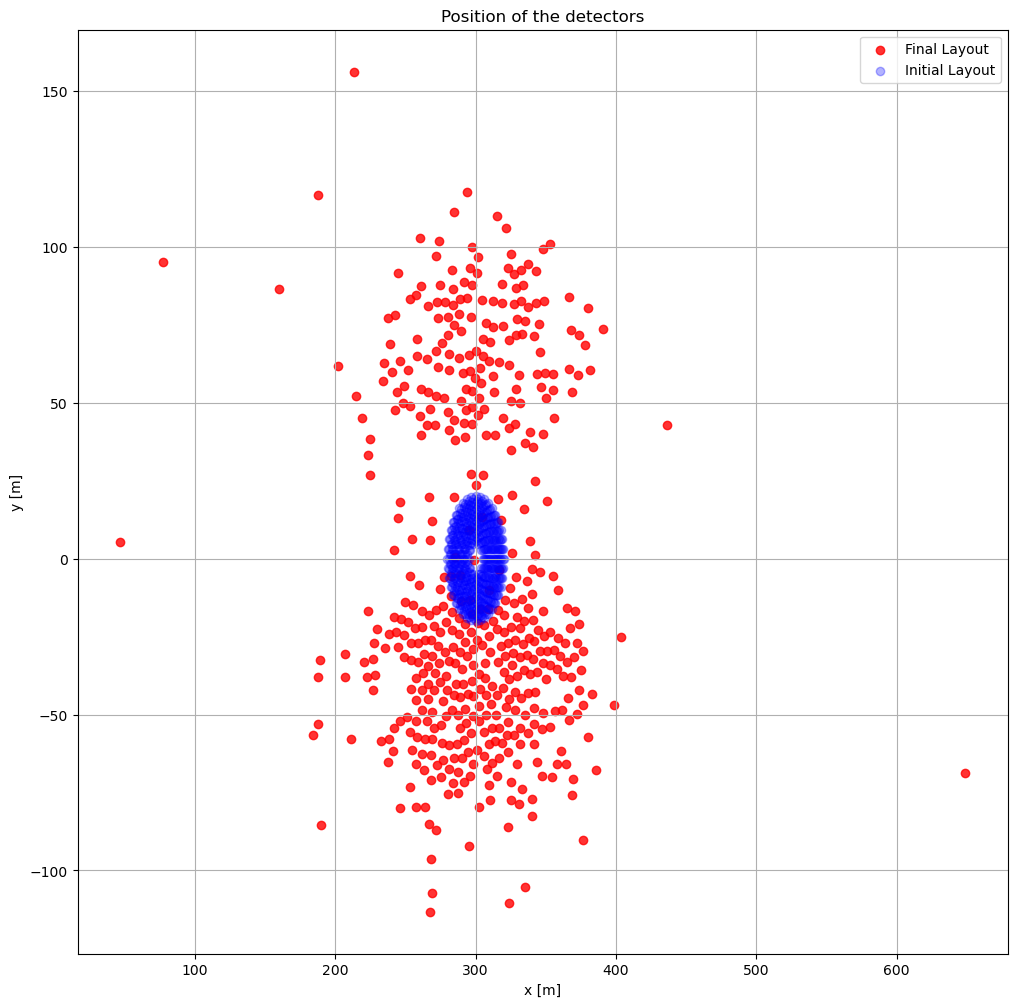

In [30]:
a, b = Layouts(n_detectors=Nunits, n_rings=20, radius=20)

plt.figure(figsize=[12, 12])
plt.scatter(
    x_det_opt.detach().cpu(), 
    y_det_opt.detach().cpu(), 
    color="red", alpha=.8, label="Final Layout"
    )
plt.scatter(a, b, color="blue", alpha=.3, label="Initial Layout")
plt.grid(); plt.xlabel("x [m]"); plt.ylabel("y [m]")
plt.title("Position of the detectors"); plt.legend()
plt.show()

In [31]:
utility_path = Path(f"{output_dir}/Python_Layout/Utilities.txt")

if utility_path.exists():
    u_t = np.loadtxt(utility_path)
    u_t = np.append(u_t, np.array(U_vals).ravel())
    np.savetxt(utility_path, u_t)
else:
    u_t = U_vals
    np.savetxt(utility_path, u_t)

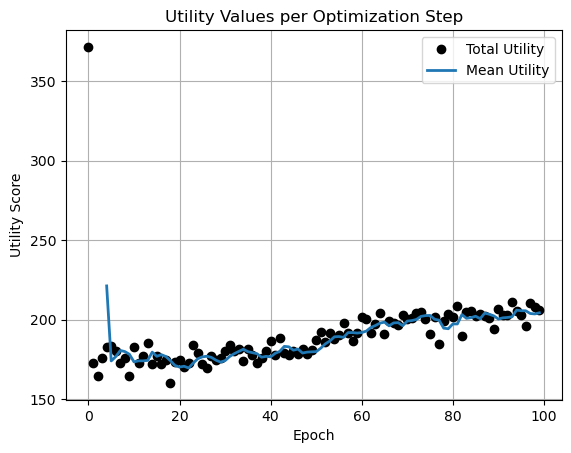

In [32]:
mean_ut = [np.mean(u_t[i - 4: i]) for i in range(4, len(u_t))]

plt.plot(u_t, color="black", linestyle="none", marker="o", linewidth=.5, label="Total Utility")
plt.plot(np.arange(4, len(u_t)), mean_ut, linestyle="-", linewidth=2, label="Mean Utility")
plt.legend(); plt.grid()
plt.xlabel("Epoch"); plt.ylabel("Utility Score")
# plt.ylim((-0.1, 1000.2))
plt.title("Utility Values per Optimization Step")
plt.show()

## Evaluate Reconstruction (end)

In [33]:
x,y = x_det_opt,y_det_opt
with torch.no_grad():
    N, T, X0, Y0, energy, sin_z, cos_z, sin_a, cos_a = generate_showers(x, y, False, number_of_showers=Ntest)

th = torch.atan2(sin_z, cos_z)
ph = torch.atan2(sin_a, cos_a)

E_norm, theta_norm, phi_norm = NormalizeLabels(energy, th, ph)
x0 = X0 / 5000
y0 = Y0 / 5000

x_exp = x.unsqueeze(0).expand(Ntest, -1)
y_exp = y.unsqueeze(0).expand(Ntest, -1)

x0_exp = x0.unsqueeze(1).expand(-1, Nunits)
y0_exp = y0.unsqueeze(1).expand(-1, Nunits)

inputs_test = torch.stack([x_exp, y_exp, N, T, x0_exp, y0_exp], dim=2).float()
inputs_test = (inputs_test - input_mean) / input_std  # add this line
labels_test = torch.stack([E_norm, theta_norm, phi_norm], dim=1).float()

Processing conditions 0 to 300 / 300...


In [34]:
model.eval()
with torch.no_grad():
    outputs = model(inputs_test.view(Ntest, -1).to(device)).cpu()

In [35]:
E_pred, theta_pred, phi_pred = DenormalizeLabels(outputs[:, 0], outputs[:, 1], outputs[:, 2])

E_p, E_r = E_pred.cpu(), energy.cpu()
Th_r, Th_p = th.cpu(), theta_pred.cpu()
Ph_r, Ph_p = ph.cpu(), phi_pred.cpu()

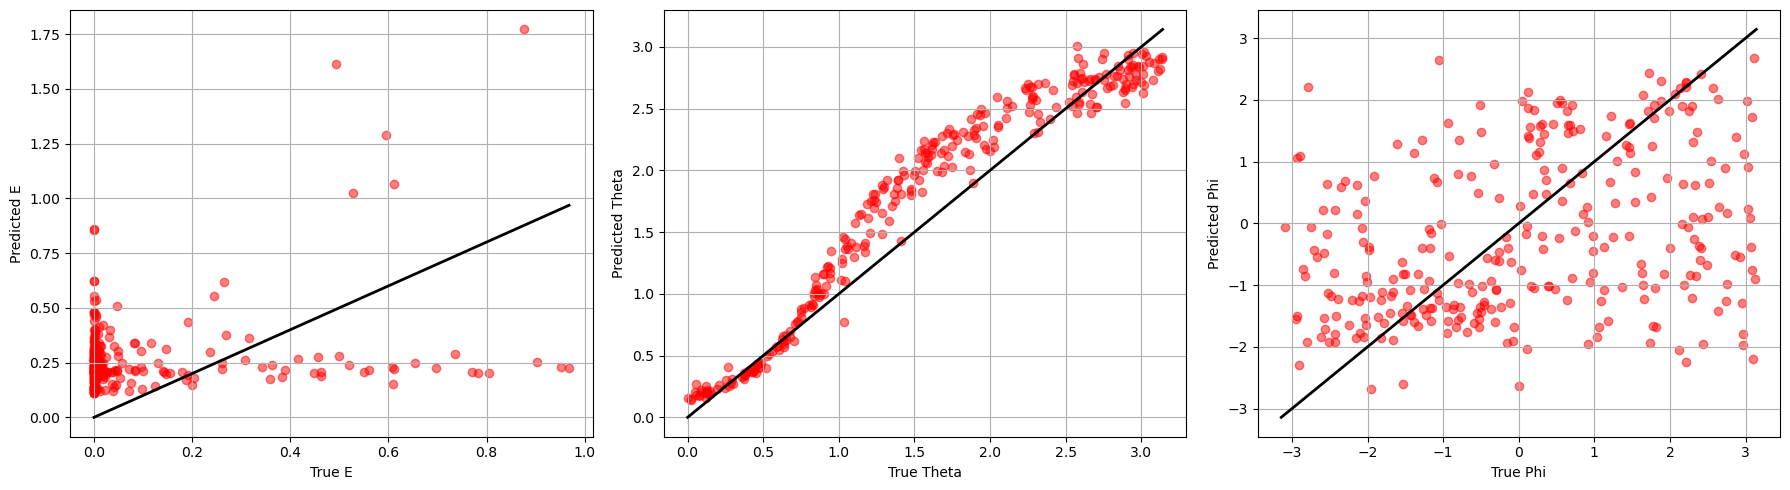

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(E_r.cpu(), E_p.cpu(), alpha=.5, color="r")
axes[0].plot([0, E_r.max().cpu()], [0, E_r.max().cpu()], "k-", lw=2)
axes[0].set_xlabel("True E"); axes[0].set_ylabel("Predicted E"); axes[0].grid()

axes[1].scatter(Th_r.cpu(), Th_p.detach().cpu(), alpha=.5, color="r")
axes[1].plot([0, np.pi], [0, np.pi], "k-", lw=2)
axes[1].set_xlabel("True Theta"); axes[1].set_ylabel("Predicted Theta"); axes[1].grid()

axes[2].scatter(Ph_r.cpu(), Ph_p.detach().cpu(), alpha=.5, color="r")
axes[2].plot([-np.pi, np.pi], [-np.pi, np.pi], "k-", lw=2)
axes[2].set_xlabel("True Phi"); axes[2].set_ylabel("Predicted Phi"); axes[2].grid()

plt.tight_layout(); plt.show()


TAMBO KPI
- efficiency, fraction of particles detected, 
- they don't care about Energy
- direction of the primary particle